In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 70

network_change = np.random.normal(0.0, 0.9, n)
cognitive_score = 72 + (network_change * 6.5) + np.random.normal(0, 5, n)

df = pd.DataFrame({
    "participant": range(1, n + 1),
    "network_change": network_change,
    "cognitive_score": cognitive_score
})

df.head()

,participant,network_change,cognitive_score
0,1,0.447043,76.712756
1,2,-0.124438,78.881337
2,3,0.582920,75.609848
3,4,1.370727,88.732943
4,5,-0.210738,57.531477


In [4]:
r, p = pearsonr(df["network_change"], df["cognitive_score"])

stats = pd.DataFrame({
    "correlation_r": [r],
    "p_value": [p]
})

stats

,correlation_r,p_value
0,0.752435,5.919184e-14


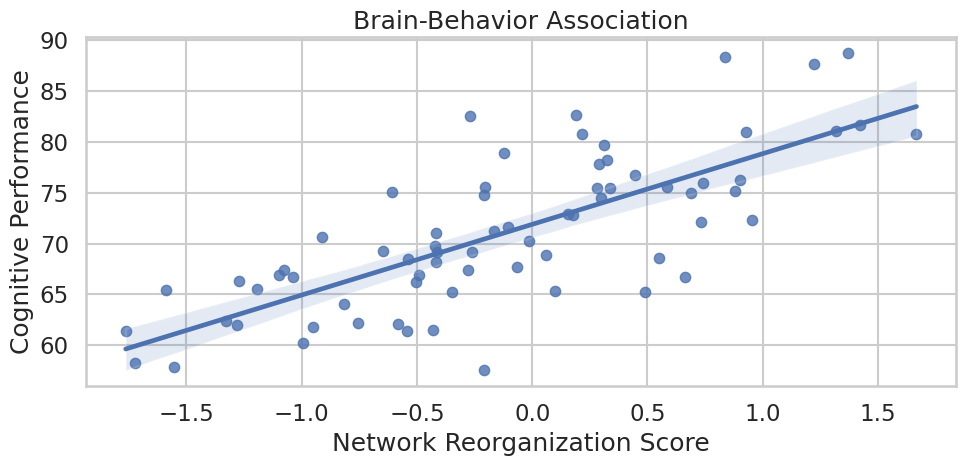

In [5]:
plt.figure(figsize=(10,5))

sns.regplot(
    data=df,
    x="network_change",
    y="cognitive_score",
    scatter_kws={"s":55}
)

plt.xlabel("Network Reorganization Score")
plt.ylabel("Cognitive Performance")
plt.title("Brain-Behavior Association")
plt.tight_layout()
plt.savefig("figures/03_brain_behavior_scatter.png", dpi=300)
plt.show()

/tmp/ipykernel_2259/2315814712.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tertile")["cognitive_score"]


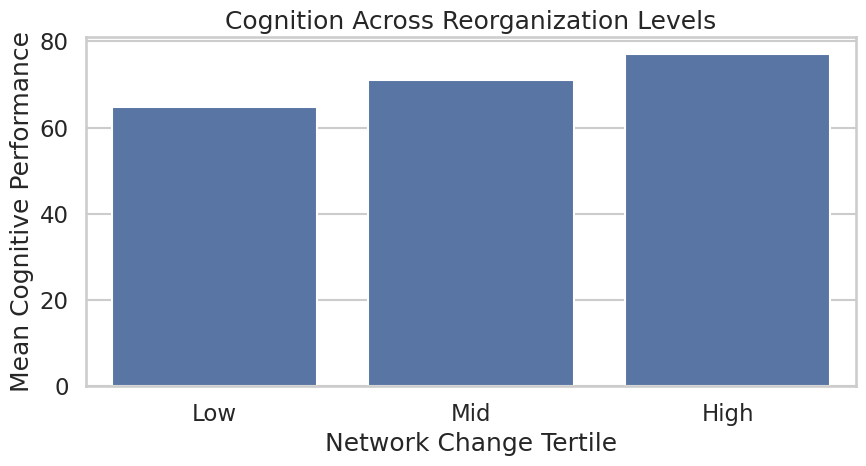

In [6]:
df["tertile"] = pd.qcut(
    df["network_change"],
    3,
    labels=["Low", "Mid", "High"]
)

tertiles = (
    df.groupby("tertile")["cognitive_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=tertiles,
    x="tertile",
    y="cognitive_score"
)

plt.xlabel("Network Change Tertile")
plt.ylabel("Mean Cognitive Performance")
plt.title("Cognition Across Reorganization Levels")
plt.tight_layout()
plt.savefig("figures/03_tertile_performance.png", dpi=300)
plt.show()

In [7]:
df.to_csv("outputs/03_brain_behavior_data.csv", index=False)
stats.to_csv("outputs/03_brain_behavior_stats.csv", index=False)

stats

,correlation_r,p_value
0,0.752435,5.919184e-14
